# DNN for `CO2_purity` and `CO2_recovery`

This notebook trains separate DNN models for `CO2_purity` and `CO2_recovery` using the selected 15 input features. The 900-row training dataset now uses 5-fold cross validation with `train 720 / validation 180` in each fold, and `mof/dataset/test.csv` is used as the external test set.

In [1]:
import os
import random
import warnings
from pathlib import Path

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers, regularizers

warnings.filterwarnings('ignore', message='Protobuf gencode version .*')

plt.style.use('seaborn-v0_8-whitegrid')

c:\Users\junhyun111\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\junhyun111\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\junhyun111\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorfl

In [2]:
SEED = 42
N_SPLITS = 5
FEATURE_COLS = [
    'tADS', 'PL', 'v0', 't_press', 't_depress',
    'h2o_ppmv', 'sox_ppmv', 'nox_ppmv', 'dust_mg_Nm3',
    'co2_mol_frac', 'capacity_factor', 'affinity_factor_co2',
    'mtc_factor', 'dax_factor', 'deactivation_index'
]
TARGET_COLS = ['CO2_purity', 'CO2_recovery']

base_dir = Path.cwd().parent

if (base_dir / 'dataset' / 'data.csv').exists():
    mof_dir = base_dir
elif (base_dir / 'mof' / 'dataset' / 'data.csv').exists():
    mof_dir = base_dir / 'mof'
else:
    raise FileNotFoundError('Could not locate mof dataset directory.')

data_path = mof_dir / 'dataset' / 'data.csv'
test_path = mof_dir / 'dataset' / 'test.csv'
model_dir = mof_dir / 'model'

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

print(f'Data path: {data_path}')
print(f'Test path: {test_path}')
print(f'Model output dir: {model_dir}')

Data path: c:\Users\junhyun111\Desktop\psa\mof\dataset\data.csv
Test path: c:\Users\junhyun111\Desktop\psa\mof\dataset\test.csv
Model output dir: c:\Users\junhyun111\Desktop\psa\mof\model


In [3]:
def prepare_dataset(path, expected_rows=None):
    dataset = pd.read_csv(path).copy()

    if 'valid_physics' in dataset.columns:
        dataset = dataset[dataset['valid_physics'].fillna(False)].copy()
    if 'status' in dataset.columns:
        dataset = dataset[dataset['status'].eq('ok')].copy()

    required_cols = FEATURE_COLS + TARGET_COLS
    missing_cols = [col for col in required_cols if col not in dataset.columns]
    if missing_cols:
        raise ValueError(f'Missing required columns in {path.name}: {missing_cols}')

    dataset = dataset.dropna(subset=required_cols).reset_index(drop=True)
    if expected_rows is not None and len(dataset) != expected_rows:
        raise ValueError(f'Expected {expected_rows} usable rows in {path.name}, found {len(dataset)} rows.')

    return dataset


df = prepare_dataset(data_path, expected_rows=900)
test_df = prepare_dataset(test_path)
kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

split_summary = pd.DataFrame({
    'dataset': ['train_cv', 'test'],
    'n_rows': [len(df), len(test_df)],
    'fold_train_rows': [int(len(df) * (N_SPLITS - 1) / N_SPLITS), np.nan],
    'fold_validation_rows': [len(df) // N_SPLITS, np.nan],
})

display(split_summary)
display(df[FEATURE_COLS + TARGET_COLS].head())
display(test_df[FEATURE_COLS + TARGET_COLS].head())

,dataset,n_rows,fold_train_rows,fold_validation_rows
0,train_cv,900,720.0,180.0
1,test,40,NaN,NaN


,tADS,PL,v0,t_press,t_depress,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,co2_mol_frac,capacity_factor,affinity_factor_co2,mtc_factor,dax_factor,deactivation_index,CO2_purity,CO2_recovery
0,121.231639,0.242283,0.011761,64.864674,38.008555,27.906160,0.988694,7.974843,0.079348,0.183007,0.840412,0.895745,0.945157,1.058946,0.522849,0.163898,0.637936
1,163.806902,0.338393,0.028594,59.693324,65.954041,9.681633,0.884149,6.019091,0.087091,0.235562,0.866624,0.913090,0.952002,1.056361,0.415982,0.490516,0.692717
2,82.472037,0.230902,0.022071,50.168231,40.971812,43.930029,0.138311,2.153061,0.049224,0.197930,0.894359,0.938445,0.968546,1.034702,0.355460,0.227966,0.690067
3,96.366813,0.162668,0.021114,53.254276,26.810740,57.544259,0.723156,7.336068,0.048012,0.249925,0.847753,0.901771,0.952673,1.045096,0.514483,0.317861,0.722666
4,113.613987,0.180127,0.031534,20.341739,60.884987,44.615595,0.020142,9.788497,0.033695,0.215893,0.883246,0.932161,0.973748,1.043018,0.407473,0.389094,0.708194


,tADS,PL,v0,t_press,t_depress,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,co2_mol_frac,capacity_factor,affinity_factor_co2,mtc_factor,dax_factor,deactivation_index,CO2_purity,CO2_recovery
0,126.962576,0.202107,0.015177,46.419845,35.362996,27.957770,0.233694,9.623800,0.051962,0.196388,0.878117,0.927229,0.968131,1.049924,0.412531,0.234751,0.682501
1,132.317849,0.233068,0.014628,20.470022,60.102201,76.145266,0.907525,5.923094,0.034094,0.208262,0.839372,0.892904,0.948657,1.036605,0.541974,0.241698,0.662479
2,141.478593,0.284023,0.026832,40.633371,71.804898,41.551212,0.625199,9.025320,0.056739,0.204630,0.852650,0.906757,0.955542,1.051710,0.496847,0.297680,0.658571
3,111.377380,0.323245,0.027595,26.483835,37.893459,65.408785,0.314783,8.087842,0.067897,0.185754,0.861125,0.917791,0.959217,1.055821,0.480246,0.302199,0.636967
4,116.307335,0.147463,0.022296,24.035233,27.876861,72.699782,0.219284,4.594333,0.085345,0.181457,0.870211,0.926313,0.958423,1.056911,0.447611,0.266216,0.671296


In [4]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
    }


def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.15),
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.10),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.Huber(),
        metrics=[keras.metrics.MeanAbsoluteError(name='mae')]
    )
    return model


def build_callbacks():
    return [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=40,
            restore_best_weights=True,
            verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=15,
            min_lr=1e-5,
            verbose=0
        )
    ]


def train_single_target(target_name):
    x_all = df[FEATURE_COLS].to_numpy(dtype=np.float32)
    y_all = df[target_name].to_numpy(dtype=np.float32).reshape(-1, 1)

    x_test = test_df[FEATURE_COLS].to_numpy(dtype=np.float32)
    y_test = test_df[target_name].to_numpy(dtype=np.float32).reshape(-1, 1)

    fold_metrics = []
    histories = []
    test_predictions = []
    best_model = None
    best_scalers = None
    best_val_mae = np.inf

    for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(x_all), start=1):
        x_train, x_val = x_all[train_idx], x_all[val_idx]
        y_train, y_val = y_all[train_idx], y_all[val_idx]

        x_scaler = StandardScaler()
        y_scaler = StandardScaler()

        x_train_scaled = x_scaler.fit_transform(x_train).astype(np.float32)
        x_val_scaled = x_scaler.transform(x_val).astype(np.float32)
        x_test_scaled = x_scaler.transform(x_test).astype(np.float32)

        y_train_scaled = y_scaler.fit_transform(y_train).astype(np.float32)
        y_val_scaled = y_scaler.transform(y_val).astype(np.float32)

        model = build_model(input_dim=x_train_scaled.shape[1])
        history = model.fit(
            x_train_scaled,
            y_train_scaled,
            validation_data=(x_val_scaled, y_val_scaled),
            epochs=500,
            batch_size=32,
            verbose=0,
            callbacks=build_callbacks()
        )

        val_pred_scaled = model.predict(x_val_scaled, verbose=0)
        val_pred = y_scaler.inverse_transform(val_pred_scaled).ravel()
        val_true = y_val.ravel()
        val_metrics = regression_metrics(val_true, val_pred)
        val_metrics['fold'] = fold_idx
        val_metrics['best_epoch'] = int(np.argmin(history.history['val_loss']) + 1)
        val_metrics['epochs_ran'] = len(history.history['loss'])
        fold_metrics.append(val_metrics)
        histories.append(history.history)

        test_pred_scaled = model.predict(x_test_scaled, verbose=0)
        test_pred = y_scaler.inverse_transform(test_pred_scaled).ravel()
        test_predictions.append(test_pred)

        if val_metrics['MAE'] < best_val_mae:
            best_val_mae = val_metrics['MAE']
            best_model = model
            best_scalers = (x_scaler, y_scaler)

    fold_metrics_df = pd.DataFrame(fold_metrics)
    ensemble_test_pred = np.mean(np.vstack(test_predictions), axis=0)
    test_metrics = regression_metrics(y_test.ravel(), ensemble_test_pred)

    summary_metrics = {
        'cv_mae_mean': fold_metrics_df['MAE'].mean(),
        'cv_mae_std': fold_metrics_df['MAE'].std(ddof=0),
        'cv_rmse_mean': fold_metrics_df['RMSE'].mean(),
        'cv_rmse_std': fold_metrics_df['RMSE'].std(ddof=0),
        'cv_r2_mean': fold_metrics_df['R2'].mean(),
        'cv_r2_std': fold_metrics_df['R2'].std(ddof=0),
        'cv_best_epoch_mean': fold_metrics_df['best_epoch'].mean(),
        'cv_epochs_ran_mean': fold_metrics_df['epochs_ran'].mean(),
        'test_mae': test_metrics['MAE'],
        'test_rmse': test_metrics['RMSE'],
        'test_r2': test_metrics['R2'],
    }

    results_df = test_df[['sample_id']].copy() if 'sample_id' in test_df.columns else pd.DataFrame(index=test_df.index)
    results_df[target_name] = y_test.ravel()
    results_df[f'pred_{target_name}'] = ensemble_test_pred
    results_df[f'error_{target_name}'] = y_test.ravel() - ensemble_test_pred

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for fold_idx, history in enumerate(histories, start=1):
        axes[0].plot(history['loss'], alpha=0.5, label=f'train fold {fold_idx}')
        axes[0].plot(history['val_loss'], linestyle='--', alpha=0.7, label=f'val fold {fold_idx}')
    axes[0].set_title(f'{target_name} fold loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Huber loss')
    axes[0].legend(ncol=2, fontsize=8)

    for fold_idx, history in enumerate(histories, start=1):
        axes[1].plot(history['mae'], alpha=0.5, label=f'train fold {fold_idx}')
        axes[1].plot(history['val_mae'], linestyle='--', alpha=0.7, label=f'val fold {fold_idx}')
    axes[1].set_title(f'{target_name} fold MAE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    y_true = y_test.ravel()
    low = min(y_true.min(), ensemble_test_pred.min())
    high = max(y_true.max(), ensemble_test_pred.max())
    axes[0].scatter(y_true, ensemble_test_pred, alpha=0.85)
    axes[0].plot([low, high], [low, high], linestyle='--', color='red')
    axes[0].set_title(f'{target_name}: test actual vs predicted')
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')

    sample_axis = results_df['sample_id'] if 'sample_id' in results_df.columns else np.arange(len(results_df))
    axes[1].plot(sample_axis, y_true, marker='o', label='Actual')
    axes[1].plot(sample_axis, ensemble_test_pred, marker='s', label='Predicted')
    axes[1].set_title(f'{target_name}: external test samples')
    axes[1].set_xlabel('Sample')
    axes[1].set_ylabel(target_name)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    best_model.save(model_dir / f'{target_name}_dnn.keras')
    return best_model, best_scalers, fold_metrics_df, results_df, summary_metrics


===== CO2_purity =====


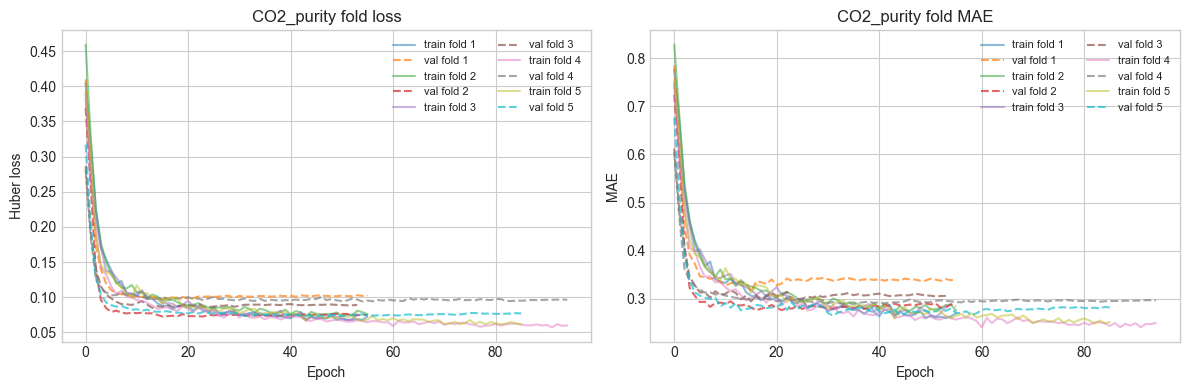

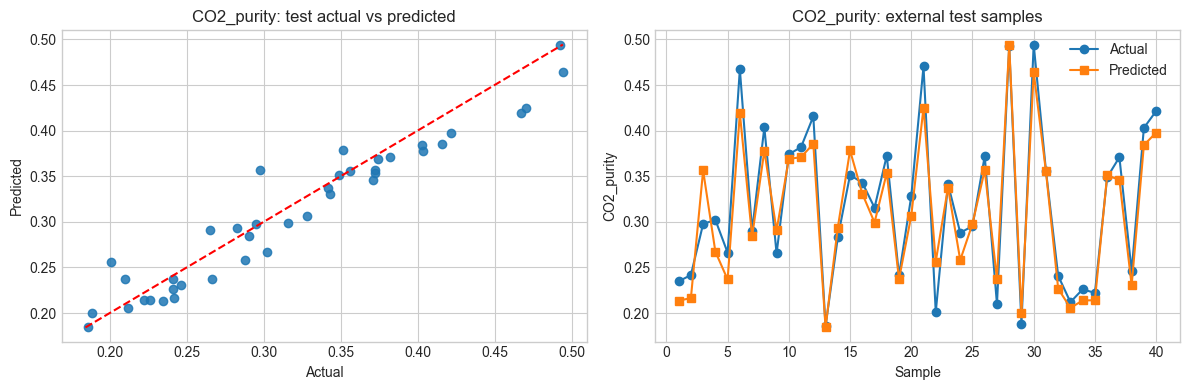

,MAE,RMSE,R2,fold,best_epoch,epochs_ran
0,0.026307,0.037657,0.830321,1,16,56
1,0.023988,0.030962,0.865845,2,16,56
2,0.025619,0.035060,0.820301,3,14,54
3,0.025286,0.037921,0.785543,4,55,95
4,0.022989,0.031908,0.854660,5,46,86


,sample_id,CO2_purity,pred_CO2_purity,error_CO2_purity
0,1,0.234751,0.213636,0.021114
1,2,0.241698,0.216401,0.025297
2,3,0.297680,0.356304,-0.058624
3,4,0.302199,0.267334,0.034866
4,5,0.266216,0.236812,0.029404


===== CO2_recovery =====


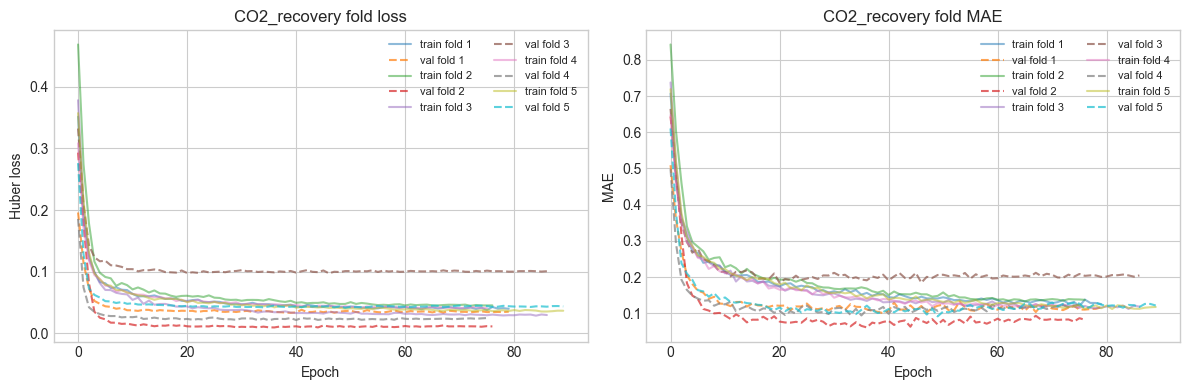

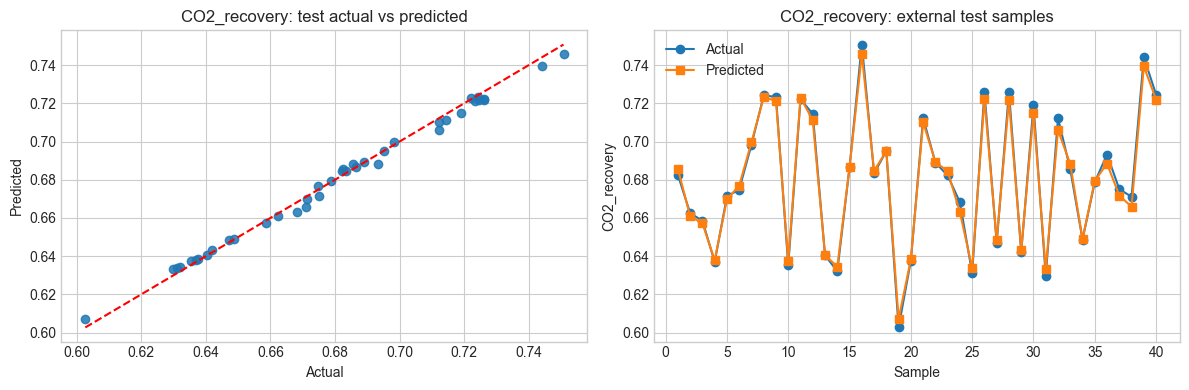

,MAE,RMSE,R2,fold,best_epoch,epochs_ran
0,0.004036,0.014211,0.853067,1,40,80
1,0.002463,0.003252,0.991707,2,37,77
2,0.006958,0.029482,0.600873,3,47,87
3,0.003802,0.008116,0.949765,4,36,76
4,0.003582,0.019148,0.783272,5,50,90


,sample_id,CO2_recovery,pred_CO2_recovery,error_CO2_recovery
0,1,0.682501,0.685692,-0.003191
1,2,0.662479,0.660869,0.001611
2,3,0.658571,0.657209,0.001362
3,4,0.636967,0.637902,-0.000935
4,5,0.671296,0.669784,0.001512


,target,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,cv_best_epoch_mean,cv_epochs_ran_mean,test_mae,test_rmse,test_r2
0,CO2_purity,0.024838,0.001193,0.034702,0.002864,0.831334,0.028124,29.4,69.4,0.019595,0.024374,0.918132
1,CO2_recovery,0.004168,0.001496,0.014842,0.009087,0.835737,0.138234,42.0,82.0,0.002429,0.002955,0.993236



Saved model files:
c:\Users\junhyun111\Desktop\psa\mof\model\CO2_purity_dnn.keras
c:\Users\junhyun111\Desktop\psa\mof\model\CO2_recovery_dnn.keras


In [5]:
all_metrics = []
all_results = {}
all_models = {}
all_fold_metrics = {}
all_scalers = {}

for target_name in TARGET_COLS:
    print(f'===== {target_name} =====')
    model, scalers, fold_metrics_df, results_df, metrics = train_single_target(target_name)
    all_models[target_name] = model
    all_scalers[target_name] = scalers
    all_fold_metrics[target_name] = fold_metrics_df
    all_results[target_name] = results_df
    all_metrics.append({'target': target_name, **metrics})
    display(fold_metrics_df)
    display(results_df.head())

metrics_df = pd.DataFrame(all_metrics)
display(metrics_df)

print('\nSaved model files:')
for target_name in TARGET_COLS:
    print(model_dir / f'{target_name}_dnn.keras')